In [8]:
import numpy as np
import pandas as pd

In [9]:
df = pd.read_csv("spa.csv", encoding='latin1')
df.head()

,label,email,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [10]:
df = df.iloc[:,:-3]

In [11]:
df[df["email"].isnull()]

,label,email


In [12]:
df.groupby("label").count() 

,email
label,
0,4825
1,747


In [13]:
df['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

In [14]:
df.duplicated().sum()

np.int64(403)

In [15]:
df=df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

# EDA

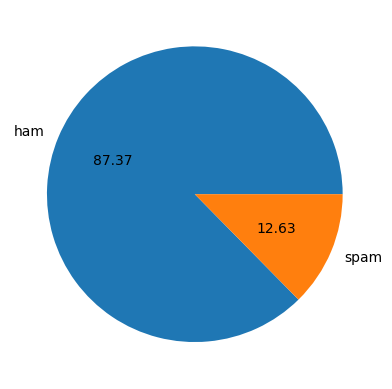

In [16]:
import matplotlib.pyplot as plt
plt.pie(df['label'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.show()

In [17]:
import nltk

In [18]:
df['num_ch']=df['email'].apply(len)
df['num_ch'].describe()

count    5169.000000
mean       78.977945
std        58.236293
min         2.000000
25%        36.000000
50%        60.000000
75%       117.000000
max       910.000000
Name: num_ch, dtype: float64

In [19]:
df[df['label']==0]['num_ch'].describe()

count    4516.000000
mean       70.459256
std        56.358207
min         2.000000
25%        34.000000
50%        52.000000
75%        90.000000
max       910.000000
Name: num_ch, dtype: float64

In [20]:
df[df['label']==1]['num_ch'].describe()

count    653.000000
mean     137.891271
std       30.137753
min       13.000000
25%      132.000000
50%      149.000000
75%      157.000000
max      224.000000
Name: num_ch, dtype: float64

In [21]:
df['num_word']= df['email'].apply(lambda x:len(nltk.word_tokenize(x)))

In [22]:
df[df['label']==0]['num_word'].describe()

count    4516.000000
mean       17.123782
std        13.493970
min         1.000000
25%         8.000000
50%        13.000000
75%        22.000000
max       220.000000
Name: num_word, dtype: float64

In [23]:
df[df['label']==1]['num_word'].describe()

count    653.000000
mean      27.667688
std        7.008418
min        2.000000
25%       25.000000
50%       29.000000
75%       32.000000
max       46.000000
Name: num_word, dtype: float64

In [24]:
df.head()

,label,email,num_ch,num_word
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [25]:
import seaborn as sns

<Axes: xlabel='num_ch', ylabel='Density'>

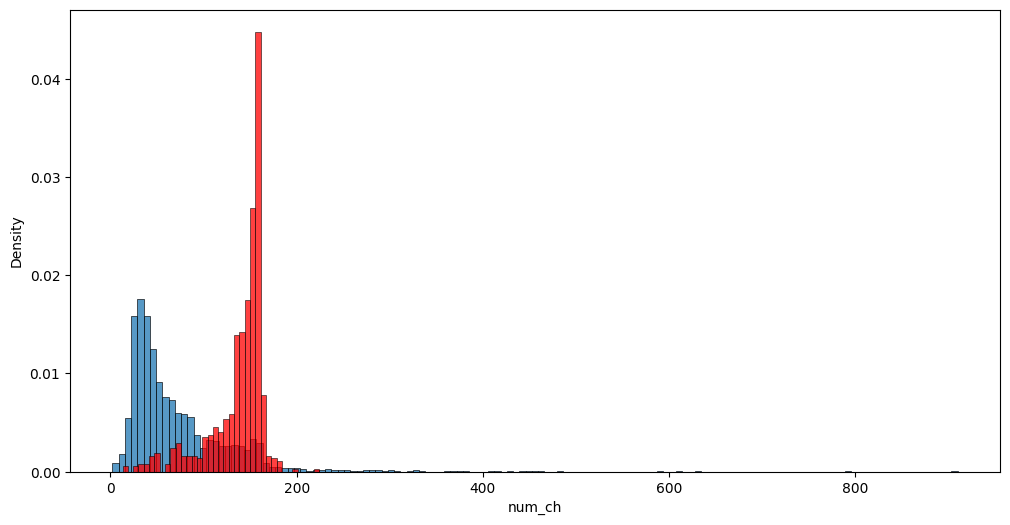

In [27]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['label']==0]['num_ch'], stat='density')
sns.histplot(df[df['label']==1]['num_ch'], stat='density',color='red')

<Axes: xlabel='num_word', ylabel='Density'>

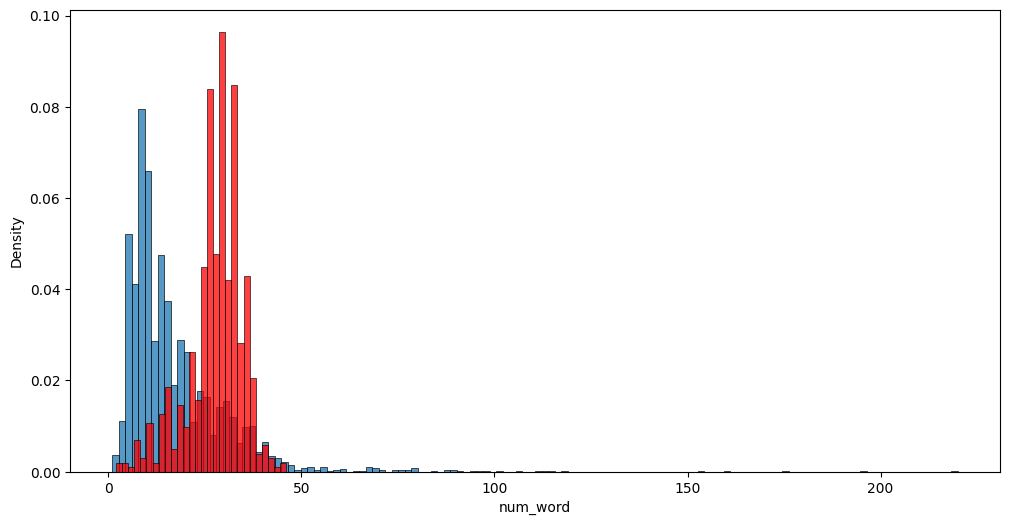

In [28]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['label']==0]['num_word'], stat='density')
sns.histplot(df[df['label']==1]['num_word'], stat='density',color='red')

<Axes: xlabel='num_word', ylabel='num_ch'>

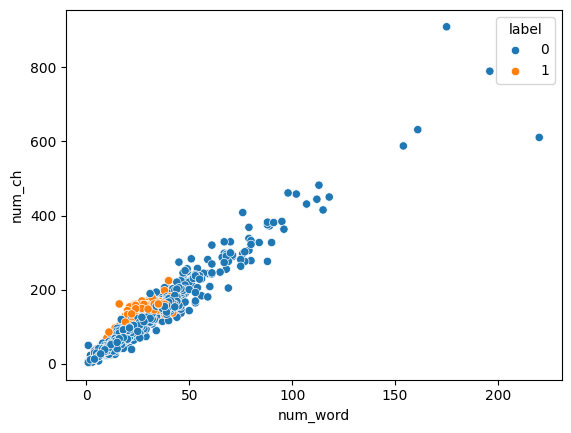

In [29]:
sns.scatterplot(
    x='num_word',
    y='num_ch',
    hue='label',
    data=df
)

<Axes: >

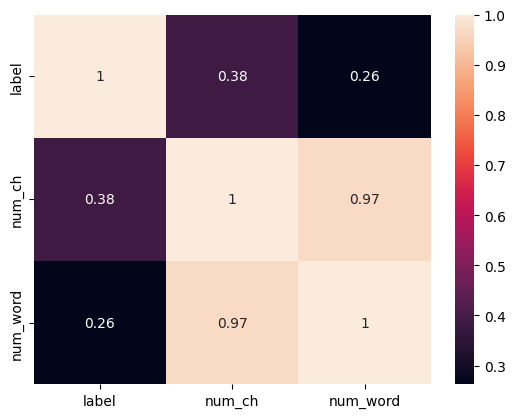

In [30]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# DATA PREPROCESSING

In [31]:
from nltk.corpus import stopwords
import string
from nltk.stem import PorterStemmer
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        if i not in stop_words and i not in string.punctuation:
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [32]:
transform_text('HI JK BYE %dsac is the? loving')

'hi jk bye dsac love'

In [33]:
df['transformed_email']=df['email'].apply(transform_text)
df.head()

,label,email,num_ch,num_word,transformed_email
0,0,"Go until jurong point, crazy.. Available only ...",111,24,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,nah think goe usf live around though


In [34]:
from wordcloud import WordCloud

In [35]:
wc = WordCloud()
spam_wc = wc.generate(df[df['label']==1]['transformed_email'].str.cat(sep=" "))

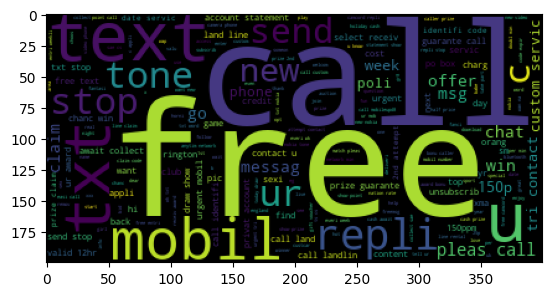

In [36]:
plt.imshow(spam_wc)

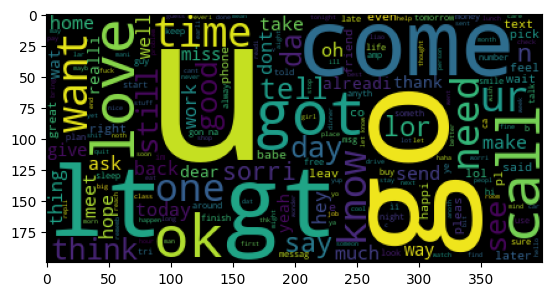

In [37]:
ham_wc = wc.generate(df[df['label']==0]['transformed_email'].str.cat(sep=" "))
plt.imshow(ham_wc)

# MODEL

In [38]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000)
X = cv.fit_transform(df['transformed_email']).toarray()

In [39]:
X.shape

(5169, 5000)

In [40]:
y = df['label'].values

In [41]:
y.shape

(5169,)

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
from sklearn.metrics import confusion_matrix, precision_score, recall_score
print(confusion_matrix(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test,y_pred))

[[885   4]
 [ 19 126]]
0.9692307692307692
0.8689655172413793


# USING TF-IDF

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['transformed_email']).toarray()
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr2 = LogisticRegression()
lr2.fit(X_train, y_train)
y_pred = lr2.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[883   6]
 [ 42 103]]
0.944954128440367
0.7103448275862069
0.9535783365570599


In [45]:
# for spam vs no spam, precision matters a lot more than recall, as if a genuine mail is marked as spam, its a really bad user experience.
#TF-IDF tends to make the model focus on very discriminative words.
#Rare words that strongly indicate spam get high importance:
#Common words get downweighted.
#So the model becomes: “If I see strong spam indicators → predict spam confidently. Otherwise → play safe and say ham.”

In [46]:
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))
print(recall_score(y_test,y_pred2))
print(accuracy_score(y_test,y_pred2))

[[888   1]
 [ 32 113]]
0.9912280701754386
0.7793103448275862
0.9680851063829787


In [47]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred2 = rf.predict(X_test)
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))
print(recall_score(y_test,y_pred2))
print(accuracy_score(y_test,y_pred2))

[[888   1]
 [ 29 116]]
0.9914529914529915
0.8
0.9709864603481625


In [48]:
import pickle

In [49]:
pickle.dump(rf, open('model2.pkl','wb'))

In [51]:
pickle.dump(tfidf, open('vectorizer2.pkl','wb'))